In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [3]:
df = pd.read_csv("diabetes_100k_updated.csv")  
df

,PatientID,Gender,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,P000001,Male,7,159,92,38,391,39.0,0.720,56,1
1,P000002,Female,6,106,67,23,0,37.2,0.778,42,1
2,P000003,Male,2,115,96,0,0,22.4,0.581,26,0
3,P000004,Male,1,130,58,20,211,37.8,0.483,21,1
4,P000005,Male,0,133,80,24,0,41.7,0.144,46,1
...,...,...,...,...,...,...,...,...,...,...,...
99995,P099996,Male,4,107,58,21,66,33.3,0.107,35,0
99996,P099997,Female,2,53,64,30,230,36.7,0.276,31,0
99997,P099998,Male,0,151,62,43,493,40.7,0.347,35,1
99998,P099999,Female,1,127,74,23,0,24.5,0.486,21,0


In [4]:
df.head()

,PatientID,Gender,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,P000001,Male,7,159,92,38,391,39.0,0.720,56,1
1,P000002,Female,6,106,67,23,0,37.2,0.778,42,1
2,P000003,Male,2,115,96,0,0,22.4,0.581,26,0
3,P000004,Male,1,130,58,20,211,37.8,0.483,21,1
4,P000005,Male,0,133,80,24,0,41.7,0.144,46,1


In [5]:
df.shape

(100000, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   PatientID                 100000 non-null  object 
 1   Gender                    100000 non-null  object 
 2   Pregnancies               100000 non-null  int64  
 3   Glucose                   100000 non-null  int64  
 4   BloodPressure             100000 non-null  int64  
 5   SkinThickness             100000 non-null  int64  
 6   Insulin                   100000 non-null  int64  
 7   BMI                       100000 non-null  float64
 8   DiabetesPedigreeFunction  100000 non-null  float64
 9   Age                       100000 non-null  int64  
 10  Outcome                   100000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 8.4+ MB


In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,3.838360,120.324260,68.588900,20.245580,79.351590,32.061154,0.489780,33.695870,0.348960
std,3.363321,31.527621,19.295858,15.725124,113.789085,7.741831,0.300398,10.150443,0.476644
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,100.000000,62.000000,0.000000,0.000000,27.500000,0.248000,25.000000,0.000000
50%,3.000000,119.000000,71.000000,23.000000,29.000000,32.300000,0.467000,33.000000,0.000000
75%,6.000000,141.000000,80.000000,33.000000,126.000000,37.000000,0.688000,41.000000,1.000000
max,17.000000,199.000000,120.000000,75.000000,846.000000,60.600000,2.174000,77.000000,1.000000


In [8]:
df["Gender"].value_counts()

Gender
Female    50063
Male      49937
Name: count, dtype: int64

In [9]:
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

In [10]:
features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Gender"
]

X = df[features]
y = df["Outcome"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
from sklearn.impute import SimpleImputer

In [13]:
# Create imputer
imputer = SimpleImputer(strategy="median")

# Apply on features
X = imputer.fit_transform(X)

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

In [17]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

In [18]:
svm_rbf = SVC(kernel="rbf", probability=True)
svm_rbf.fit(X_train_scaled, y_train)

y_pred_svm = svm_rbf.predict(X_test_scaled)
y_prob_svm = svm_rbf.predict_proba(X_test_scaled)[:, 1]

In [19]:
svm_linear = SVC(kernel="linear", probability=True)
svm_linear.fit(X_train_scaled, y_train)

y_pred_linear = svm_linear.predict(X_test_scaled)
y_prob_linear = svm_linear.predict_proba(X_test_scaled)[:, 1]

In [20]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("========== LOGISTIC REGRESSION ==========")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("AUC      :", roc_auc_score(y_test, y_prob_lr))


print("\n========== KNN ==========")
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1 Score :", f1_score(y_test, y_pred_knn))
print("AUC      :", roc_auc_score(y_test, y_prob_knn))


print("\n========== SVM (RBF) ==========")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))
print("AUC      :", roc_auc_score(y_test, y_prob_svm))


print("\n========== SVM (LINEAR) ==========")
print("Accuracy :", accuracy_score(y_test, y_pred_linear))
print("Precision:", precision_score(y_test, y_pred_linear))
print("Recall   :", recall_score(y_test, y_pred_linear))
print("F1 Score :", f1_score(y_test, y_pred_linear))
print("AUC      :", roc_auc_score(y_test, y_prob_linear))


print("\n========== RANDOM FOREST ==========")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("AUC      :", roc_auc_score(y_test, y_prob_rf))

========== LOGISTIC REGRESSION ==========
Accuracy : 0.81505
Precision: 0.7751677852348994
Recall   : 0.6619859578736209
F1 Score : 0.7141201020171575
AUC      : 0.8688215787828888

========== KNN ==========
Accuracy : 0.8088
Precision: 0.7672369981365408
Recall   : 0.6489468405215647
F1 Score : 0.7031516845210372
AUC      : 0.8526671548101247

========== SVM (RBF) ==========
Accuracy : 0.8293
Precision: 0.8196162811547427
Recall   : 0.6549648946840522
F1 Score : 0.7280981204205161
AUC      : 0.8827350428742424

========== SVM (LINEAR) ==========
Accuracy : 0.8154
Precision: 0.7807961729027849
Recall   : 0.6548216076801834
F1 Score : 0.712281795511222
AUC      : 0.8688934533751451

========== RANDOM FOREST ==========
Accuracy : 0.8533
Precision: 0.8179531520201226
Recall   : 0.7455222811291016
F1 Score : 0.7800599700149925
AUC      : 0.9217561788242497


In [21]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "SVM (RBF)",
        "SVM (Linear)",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_linear),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_linear),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_linear),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_linear),
        f1_score(y_test, y_pred_rf)
    ],
    "AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_knn),
        roc_auc_score(y_test, y_prob_svm),
        roc_auc_score(y_test, y_prob_linear),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,Logistic Regression,0.81505,0.775168,0.661986,0.714120,0.868822
1,KNN,0.80880,0.767237,0.648947,0.703152,0.852667
2,SVM (RBF),0.82930,0.819616,0.654965,0.728098,0.882735
3,SVM (Linear),0.81540,0.780796,0.654822,0.712282,0.868893
4,Random Forest,0.85330,0.817953,0.745522,0.780060,0.921756


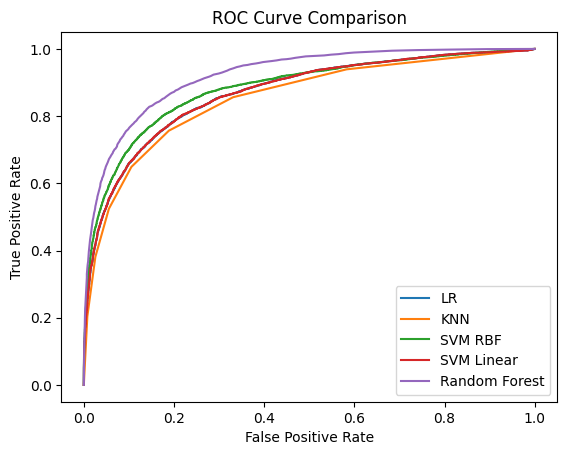

In [22]:
plt.plot(*roc_curve(y_test, y_prob_lr)[:2], label="LR")
plt.plot(*roc_curve(y_test, y_prob_knn)[:2], label="KNN")
plt.plot(*roc_curve(y_test, y_prob_svm)[:2], label="SVM RBF")
plt.plot(*roc_curve(y_test, y_prob_linear)[:2], label="SVM Linear")
plt.plot(*roc_curve(y_test, y_prob_rf)[:2], label="Random Forest")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

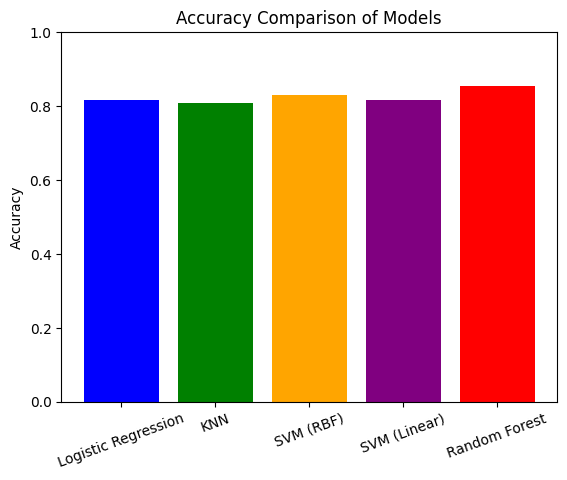

In [23]:
colors = ["blue", "green", "orange", "purple", "red"]

plt.figure()
plt.bar(results["Model"], results["Accuracy"], color=colors)
plt.xticks(rotation=20)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Models")
plt.ylim(0, 1)
plt.show()

In [26]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Random Forest Confusion Matrix:")
print(cm_rf)

Random Forest Confusion Matrix:
[[11863  1158]
 [ 1776  5203]]


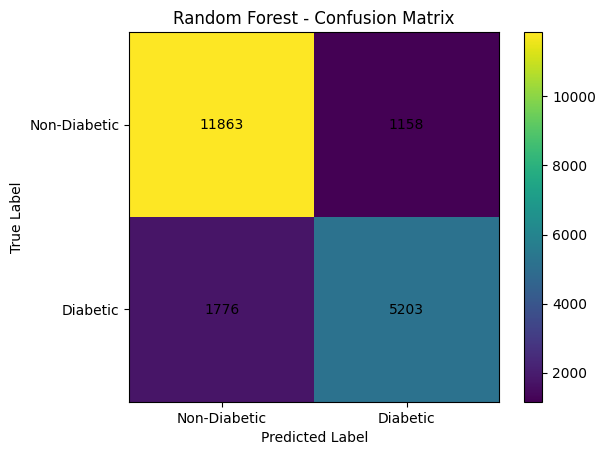

In [27]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.imshow(cm_rf)
plt.title("Random Forest - Confusion Matrix")
plt.colorbar()

classes = ["Non-Diabetic", "Diabetic"]
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        plt.text(j, i, cm_rf[i, j],
                 ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [30]:
feature_names = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Gender"
]

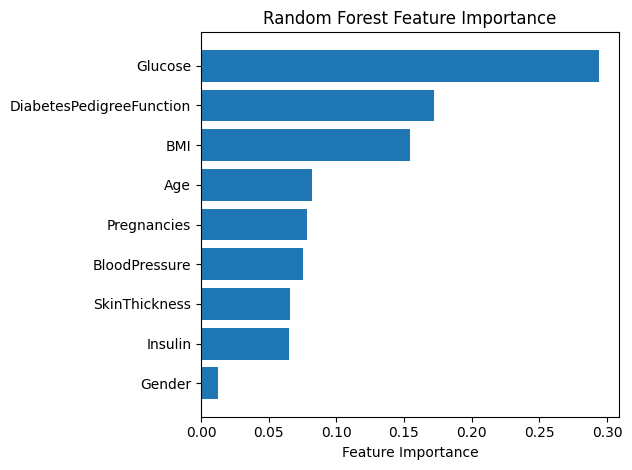

In [31]:
import matplotlib.pyplot as plt
import numpy as np

rf_importance = rf.feature_importances_


indices = np.argsort(rf_importance)

plt.figure()
plt.barh(range(len(indices)), rf_importance[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

In [34]:
import numpy as np


new_patient = np.array([[2, 120, 70, 25, 80, 28.0, 0.5, 35, 0]])


new_patient = imputer.transform(new_patient)


prediction = rf.predict(new_patient)

print("Prediction:", prediction)

if prediction[0] == 1:
    print("Diabetic")
else:
    print("Non-Diabetic")

Prediction: [0]
Non-Diabetic


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [37]:

import numpy as np
import pandas as pd

print("Enter patient details:")

preg = float(input("Pregnancies: "))
glucose = float(input("Glucose Level: "))
bp = float(input("Blood Pressure: "))
skin = float(input("Skin Thickness: "))
insulin = float(input("Insulin Level: "))
bmi = float(input("BMI: "))
dpf = float(input("Diabetes Pedigree Function: "))
age = float(input("Age: "))
gender = int(input("Gender (Male=1, Female=0): "))

# Feature names EXACTLY as used in training
feature_names = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Gender"
]

# Create DataFrame instead of NumPy array
user_df = pd.DataFrame([[preg, glucose, bp, skin, insulin, bmi, dpf, age, gender]],
                       columns=feature_names)

# Preprocessing
user_df = imputer.transform(user_df)
user_df = scaler.transform(user_df)

# Prediction
prediction = svm_rbf.predict(user_df)
probability = svm_rbf.predict_proba(user_df)[0][1] * 100

if prediction[0] == 1:
    print("Result: Diabetic")
else:
    print("Result: Non-Diabetic")

print(f"Diabetes Risk: {probability:.2f}%")

Enter patient details:


Pregnancies:  1
Glucose Level:  95
Blood Pressure:  70
Skin Thickness:  20
Insulin Level:  85
BMI:  23
Diabetes Pedigree Function:  0.3
Age:  28
Gender (Male=1, Female=0):  0


Result: Non-Diabetic
Diabetes Risk: 15.25%


In [36]:
import numpy as np
import pandas as pd

print("Enter patient details:")

preg = float(input("Pregnancies: "))
glucose = float(input("Glucose Level: "))
bp = float(input("Blood Pressure: "))
skin = float(input("Skin Thickness: "))
insulin = float(input("Insulin Level: "))
bmi = float(input("BMI: "))
dpf = float(input("Diabetes Pedigree Function: "))
age = float(input("Age: "))
gender = int(input("Gender (Male=1, Female=0): "))


feature_names = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Gender"
]


user_df = pd.DataFrame([[preg, glucose, bp, skin, insulin, bmi, dpf, age, gender]],
                       columns=feature_names)


user_df = imputer.transform(user_df)
user_df = scaler.transform(user_df)


prediction = svm_rbf.predict(user_df)
probability = svm_rbf.predict_proba(user_df)[0][1] * 100

if prediction[0] == 1:
    print("Result: Diabetic")
else:
    print("Result: Non-Diabetic")

print(f"Diabetes Risk: {probability:.2f}%")

Enter patient details:


Pregnancies:  6
Glucose Level:  170
Blood Pressure:  88
Skin Thickness:  35
Insulin Level:  210
BMI:  36.6
Diabetes Pedigree Function:  1.1
Age:  52
Gender (Male=1, Female=0):  0


Result: Diabetic
Diabetes Risk: 96.86%


In [39]:
#usinng random forest 
import numpy as np
import pandas as pd

print("Enter patient details:")

preg = float(input("Pregnancies: "))
glucose = float(input("Glucose Level: "))
bp = float(input("Blood Pressure: "))
skin = float(input("Skin Thickness: "))
insulin = float(input("Insulin Level: "))
bmi = float(input("BMI: "))
dpf = float(input("Diabetes Pedigree Function: "))
age = float(input("Age: "))
gender = int(input("Gender (Male=1, Female=0): "))


feature_names = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Gender"
]


user_df = pd.DataFrame([[preg, glucose, bp, skin, insulin, bmi, dpf, age, gender]],
                       columns=feature_names)


user_df = imputer.transform(user_df)
user_df = scaler.transform(user_df)


prediction = rf.predict(user_df)
probability = rf.predict_proba(user_df)[0][1] * 100

if prediction[0] == 1:
    print("Result: Diabetic")
else:
    print("Result: Non-Diabetic")

print(f"Diabetes Risk: {probability:.2f}%")

Enter patient details:


Pregnancies:  1
Glucose Level:  23
Blood Pressure:  82
Skin Thickness:  23
Insulin Level:  22
BMI:  16
Diabetes Pedigree Function:  0.2
Age:  38
Gender (Male=1, Female=0):  1


Result: Non-Diabetic
Diabetes Risk: 5.00%


In [41]:
import numpy as np
import pandas as pd

print("Enter patient details:")

preg = float(input("Pregnancies: "))
glucose = float(input("Glucose Level: "))
bp = float(input("Blood Pressure: "))
skin = float(input("Skin Thickness: "))
insulin = float(input("Insulin Level: "))
bmi = float(input("BMI: "))
dpf = float(input("Diabetes Pedigree Function: "))
age = float(input("Age: "))
gender = int(input("Gender (Male=1, Female=0): "))


feature_names = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Gender"
]


user_df = pd.DataFrame([[preg, glucose, bp, skin, insulin, bmi, dpf, age, gender]],
                       columns=feature_names)


user_df = imputer.transform(user_df)
user_df = scaler.transform(user_df)


prediction = rf.predict(user_df)
probability = rf.predict_proba(user_df)[0][1] * 100

if prediction[0] == 1:
    print("Result: Diabetic")
else:
    print("Result: Non-Diabetic")

print(f"Diabetes Risk: {probability:.2f}%")

Enter patient details:


Pregnancies:  7
Glucose Level:  180
Blood Pressure:  90
Skin Thickness:  35
Insulin Level:  220
BMI:  37.5
Diabetes Pedigree Function:  1.2
Age:  55
Gender (Male=1, Female=0):  1


Result: Non-Diabetic
Diabetes Risk: 28.50%
